### [BIC30007 - _Sequence Alignment Fundamentals, Algorithm, and Application_](http://ugm.id/BIC30007practical02)
# 02.2 _Dot Plot_

## Pengantar
Pada tutorial sebelumnya, kita telah mengaplikasikan pensejajaran sekuen untuk identifikasi spesies (DNA Barcoding). Pensejajaran sekuen baru dengan sekuen biologis yang telah diketahui dapat memberikan gambaran mengenai fungsi dan asal-usul evolusionernya. Pada tutorial ini, kita akan mempelajari prinsip dan teknik komputasi yang digunakan untuk melakukan dan mengevaluasi pensejajaran sekuen.

## 1. Dot Plot
Metode Dot Plot digunakan untuk melakukan perbandingan visual antara dua sekuen. Pada contoh yang paling sederhana, 2 sekuen dibandingkan dengan menggunakan matrix, dimana satu sekuen berada pada sumbu vertikal, dan satunya lagi pada sumbu horizontal. Saat terjadi kesamaan _(match)_ pada posisi horizontal, maka sebuah titik akan dibuat. 

![dotplot_sederhana](https://raw.githubusercontent.com/lab-biotek-bio-ugm/BIC30007-2/dev-matin2/acara_02/images/DOT_PLOT.png)

Metode dotplot yang lebih kompleks menggunakan _**"sliding windows"**_ dan _**"threshold value"**_ untuk menentukan apakah sebuah segmen dari kedua sekuen yang dibandingkan memiliki kesamaan atau tidak.

In [1]:
# load Library
from IPython.display import Image
from pathlib import Path

### Pengaturan folder input dan output
# Set up paths
data_dir = Path('data')
# Jika output dari data_dir.is_dir() adalah False, sesuaikan value dari data_dir dengan lokasi yang benar
assert data_dir.is_dir(), f"Folder {data_dir} tidak ditemukan, sesuaikan value dari data_dir dengan lokasi yang benar!"

# Set up output directory
output_dir = Path('results/02.2')
output_dir.mkdir(parents=True, exist_ok=True)

### 1.1 Analisis struktur gen: Ekson dan Intron
Kita dapat mempelajari struktur ekson dan intron dari sebuah gen secara visual dengan menggunakan EMBOSS - dotmatcher.

Pada script di bawah, kita akan membandingkan struktur bagian genom Arabidopsis (AT3G52905.1) dengan salah satu cDNA:

_**PS: karakter "!" di depan berarti bahwa script berjalan di terminal**_

Draw a threshold dotplot of two sequences
Created results/02.2/01_AT3G4905.1.png


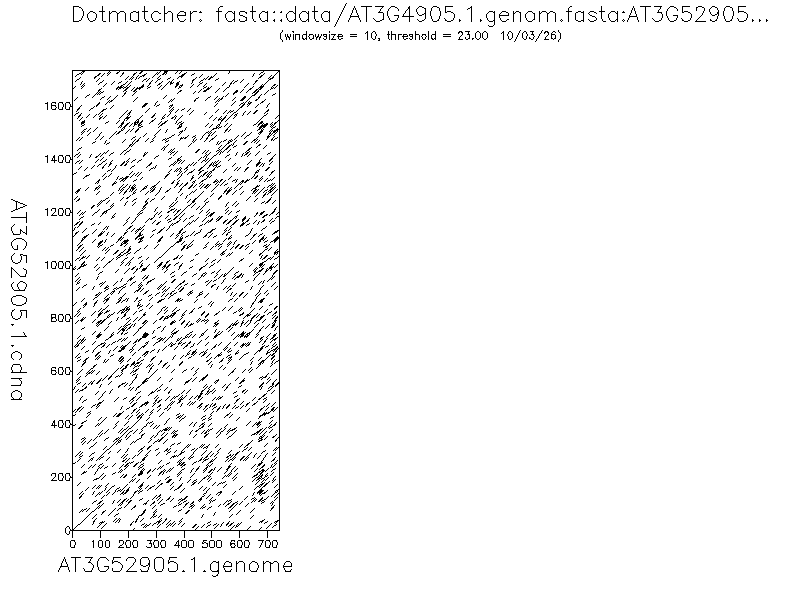

In [2]:
# jika EMBOSS belum terinstall, silahkan install terlebih dahulu dengan mengetik pada terminal:
# conda install -c bioconda emboss
! dotmatcher {data_dir}/AT3G4905.1.genom.fasta {data_dir}/AT3G4905.1.cdna.fasta -graph png -goutfile {output_dir}/01_AT3G4905
Image(filename=str(output_dir / '01_AT3G4905.1.png'))

#### Diskusi
* Mengapa banyak _"noise"_ yang muncul pada dot plot di atas?
* Parameter apa yang dapat kita gunakan untuk memperbaiki tampilan dot plot di atas?

Coba jalankan script di bawah ini:

Draw a threshold dotplot of two sequences
Created results/02.2/02_AT3G4905_strict.1.png


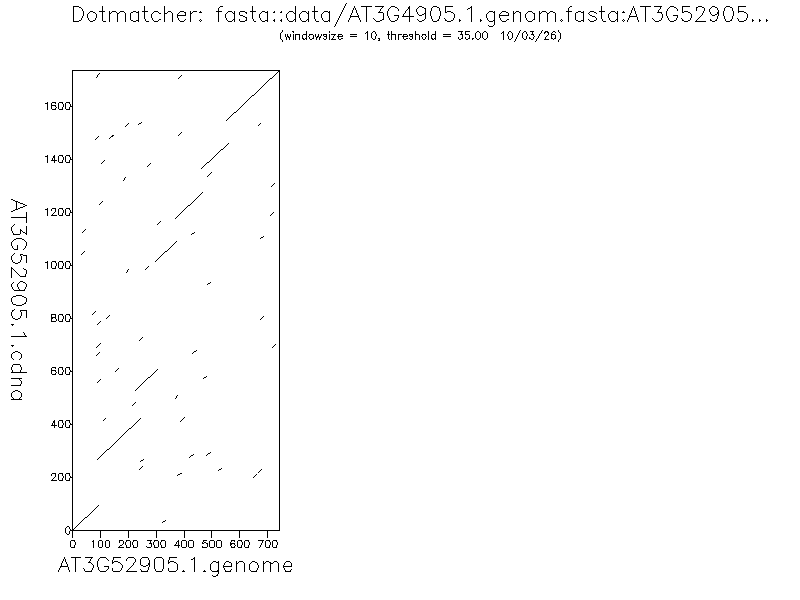

In [3]:
! dotmatcher -windowsize 10 -threshold 35 {data_dir}/AT3G4905.1.genom.fasta {data_dir}/AT3G4905.1.cdna.fasta -graph png -goutfile {output_dir}/02_AT3G4905_strict
Image(filename=str(output_dir / '02_AT3G4905_strict.1.png'))

#### Diskusi
* Coba cari tahu apa yang dimaksud dengan _"window size"_ dan _"threshold value"_!
* Kenapa garis diagonal utama terpisah menjadi beberapa fragmen? 

### 1.2 Membandingkan gen yang berkerabat dekat
Kita juga dapat mempelajari region homolog antara dua protein, satu dari manusia dan satu dari anjing. Mari kita bandingkan coding sequence (CDS) dari gen CDKL4 antara manusia dan anjing:

Draw a threshold dotplot of two sequences
Created results/02.2/03_CDKL4.1.png


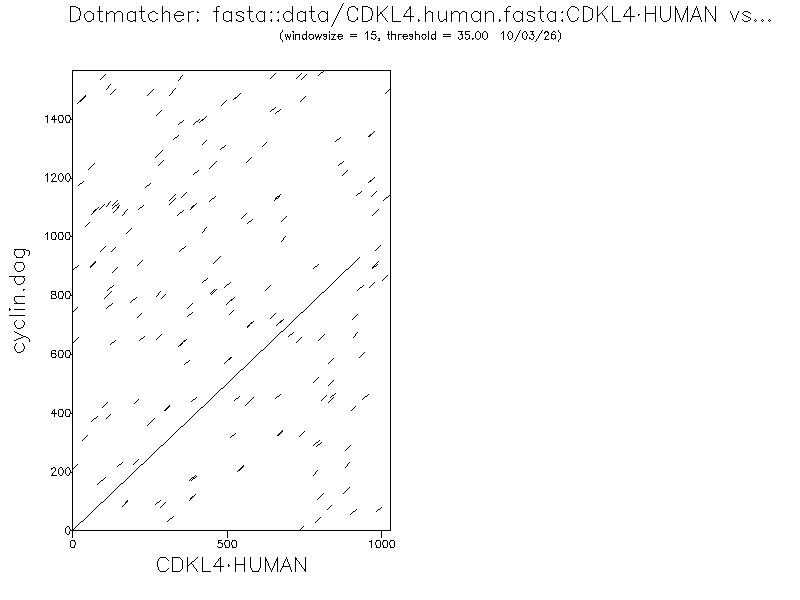

In [4]:
! dotmatcher -windowsize 15 -threshold 35 {data_dir}/CDKL4.human.fasta {data_dir}/cyclin.dog.fasta -graph png -goutfile {output_dir}/03_CDKL4
Image(filename=str(output_dir / '03_CDKL4.1.png'))

#### Diskusi
* Apakah terdapat kemiripan antara CDS manusia dan anjing?
* Mengapa sebagian region DNA/genom memiliki kemiripan yang tinggi meskipun berasal dari spesies yang berbeda?

Selanjutnya, kita akan mencoba membandingkan sekuen mRNA dari α dan β-globin

Draw a threshold dotplot of two sequences
Created results/02.2/04_globin.1.png


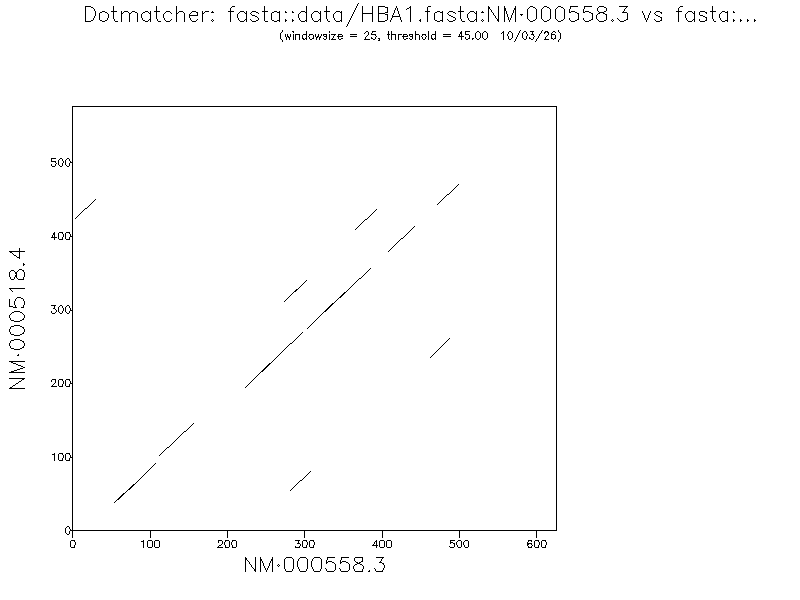

In [5]:
! dotmatcher -windowsize 25 -threshold 45 {data_dir}/HBA1.fasta {data_dir}/HBB.fasta -graph png -goutfile {output_dir}/04_globin
Image(filename=str(output_dir / '04_globin.1.png'))

#### Diskusi
* Informasi apa yang dapat dijelaskan mengenai perbedaan α dan β-globin pada dot plot di atas?

### 1.3 _Tandem Repeats_
Visualisasi pensejajaran juga dapat kita gunakan untuk mempelajari bagian genom/DNA yang diulang _(repeated/inverted)_.
Selanjutnya, kita akan mempelajari _repeats_ dari _human zinc finger protein Q9P255_.

Sejajarkan protein dengan dirinya sendiri menggunakan script berikut:

Draw a threshold dotplot of two sequences
Created results/02.2/05_tandem_repeats.1.png


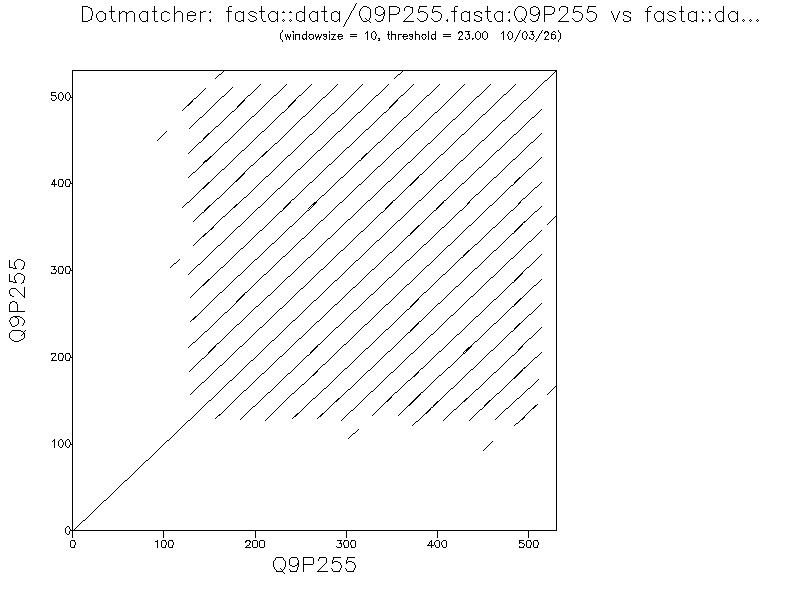

In [6]:
! dotmatcher {data_dir}/Q9P255.fasta {data_dir}/Q9P255.fasta -graph png -goutfile {output_dir}/05_tandem_repeats
Image(filename=str(output_dir / '05_tandem_repeats.1.png'))

Diskusi:
* Bagaimana interpretasi dari pola yang dihasilkan?
* Bagaimanakah distribusi dari repeats yang muncul? Lebih banyak pada ujung N atau C? Ada berapa repeats yang muncul?
* Coba ubah _threshold value_ dan perhatikan pengaruhnya terhadap visualisasi pensejajaran alignment!

In [7]:
# write your code here:




#### Klik link di bawah untuk kembali ke Modul Utama:
### [BIC30007 - _Sequence Alignment Fundamentals, Algorithm, and Application_](http://ugm.id/BIC30007practical02)